Device: cuda
Using global train min/max for encoder input normalization: min=-1.230065e-07, max=1.210273e-07
Training (paper schedule): epochs= 200 batch_size= 256
Saved checkpoint -> /kaggle/output/jdcnet_paper_best.pth  (0.11 MB)
Epoch 1/200 | lr=5.00e-05 | train_loss=1.8267e-01 | val_NMSE=9.651 dB | best=9.651 dB | t_epoch=7.5s
Saved checkpoint -> /kaggle/output/jdcnet_paper_best.pth  (0.11 MB)
Saved checkpoint -> /kaggle/output/jdcnet_paper_best.pth  (0.11 MB)
Saved checkpoint -> /kaggle/output/jdcnet_paper_best.pth  (0.11 MB)
Saved checkpoint -> /kaggle/output/jdcnet_paper_best.pth  (0.11 MB)
Saved checkpoint -> /kaggle/output/jdcnet_paper_best.pth  (0.11 MB)
Saved checkpoint -> /kaggle/output/jdcnet_paper_best.pth  (0.11 MB)
Saved checkpoint -> /kaggle/output/jdcnet_paper_best.pth  (0.11 MB)
Saved checkpoint -> /kaggle/output/jdcnet_paper_best.pth  (0.11 MB)
Saved checkpoint -> /kaggle/output/jdcnet_paper_best.pth  (0.11 MB)
Epoch 10/200 | lr=6.35e-04 | train_loss=1.0064e-04 | va

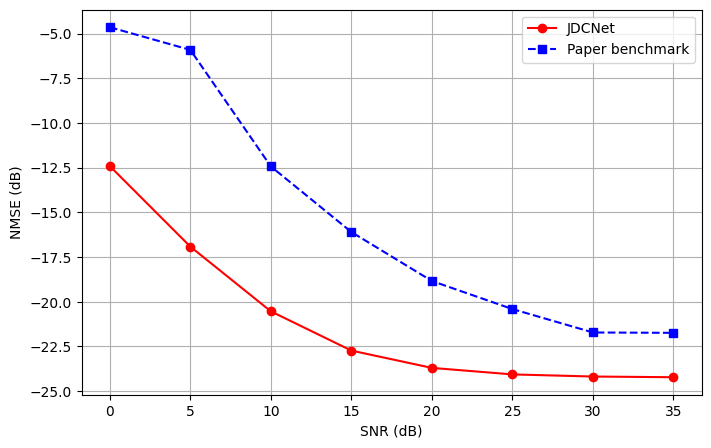

In [1]:
# jdcnet_paper_final_with_flexible_loader.py
# Paper-faithful JDCNet reproduction (encoder/decoder/quant + training schedule)
# Adds a robust loader to handle DataParallel 'module.' prefix mismatch on load,
# and safe saving to /kaggle/output. No other logic changed.

import os, random, math, time, shutil
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# ---------------- reproducibility ----------------
seed = 42
random.seed(seed); np.random.seed(seed)
torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ---------------- flexible loader helper ----------------
def load_state_dict_flexible(path, model, map_location=None, verbose=True):
    """
    Load a saved state_dict into `model` handling the presence/absence of DataParallel 'module.' prefixes.
    - path: path to the saved state_dict (torch.save(state_dict, path))
    - model: instantiated model (may be wrapped in nn.DataParallel)
    - map_location: device string or torch.device
    """
    if map_location is None:
        map_location = 'cuda' if torch.cuda.is_available() else 'cpu'
    sd = torch.load(path, map_location=map_location)

    # If saved file is a checkpoint dict (containing 'model_state_dict' or similar), extract the underlying dict.
    if isinstance(sd, dict) and not all(isinstance(v, torch.Tensor) for v in sd.values()):
        # try common keys
        if 'model_state_dict' in sd:
            sd = sd['model_state_dict']
        elif 'state_dict' in sd:
            sd = sd['state_dict']
        # else assume sd is already a mapping of param->tensor or other. Continue.

    if not isinstance(sd, dict):
        raise RuntimeError(f"Loaded object from {path} is not a state_dict mapping.")

    sd_keys = list(sd.keys())
    if len(sd_keys) == 0:
        raise RuntimeError("Loaded state_dict is empty")

    saved_has_module = sd_keys[0].startswith('module.')
    model_is_datapar = isinstance(model, nn.DataParallel)

    if verbose:
        print(f"[loader] Loaded state_dict from {path}. saved_has_module={saved_has_module}, model_is_datapar={model_is_datapar}")

    # Adjust keys if needed
    if saved_has_module and not model_is_datapar:
        # strip 'module.' prefix
        new_sd = {k[len('module.'):]: v for k, v in sd.items()}
        sd = new_sd
        if verbose: print("[loader] Stripped 'module.' prefix from saved keys.")
    elif (not saved_has_module) and model_is_datapar:
        # add 'module.' prefix
        new_sd = {'module.' + k: v for k, v in sd.items()}
        sd = new_sd
        if verbose: print("[loader] Added 'module.' prefix to saved keys to match DataParallel model.")

    # Attempt strict load; if it fails, attempt non-strict and print diagnostics
    try:
        model.load_state_dict(sd)
        if verbose: print("[loader] State dict loaded successfully (strict).")
    except Exception as e:
        if verbose:
            print("[loader] Strict load failed. Attempting non-strict load for diagnostics...")
        res = model.load_state_dict(sd, strict=False)
        if verbose:
            print("[loader] Non-strict load result:", res)
        # re-raise original exception for clarity
        raise e

# ---------------- STE Quantizer ----------------
class QuantizeSTE(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, q_bits):
        levels = 2 ** q_bits - 1
        x_clamped = torch.clamp(x, 0.0, 1.0)
        q = torch.round(x_clamped * levels) / levels
        return q
    @staticmethod
    def backward(ctx, grad_output):
        return grad_output, None

# ---------------- ResBlock (paper: two 3x3 convs + ReLU + skip) ----------------
class PaperResBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, stride=1, padding=1)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, stride=1, padding=1)
    def forward(self, x):
        identity = x
        out = self.relu(self.conv1(x))
        out = self.conv2(out)
        return self.relu(out + identity)

# ---------------- JDCNet (paper faithful) ----------------
class JDCNet_Paper(nn.Module):
    def __init__(self, M=16, N=64, N0=2, gamma=1/16, q_bits=8, B=4, decoder_ch=16, quant_enabled=True):
        """
        Paper-faithful JDCNet:
         - encoder: 2 conv layers (4x4 stride2 pad1)
         - bottleneck channels C computed from gamma
         - quantization: uniform on flattened v (per-sample min/max)
         - decoder: reshape -> 2 tconv -> B ResBlocks -> final upsample tconv + 3x3 conv
        """
        super().__init__()
        self.M, self.N, self.N0 = M, N, N0
        self.Np = N // N0
        self.q_bits = q_bits
        self.quant_enabled = quant_enabled
        # paper: gamma = 1/16 -> C = gamma * 32 * N0  (=> C=4 when N0=2)
        self.C = int(gamma * 32 * N0)

        # Encoder: 2 -> 16 -> C
        self.encoder = nn.Sequential(
            nn.Conv2d(2, 16, kernel_size=4, stride=2, padding=1),  # (B,16,M/2,Np/2)
            nn.ReLU(inplace=True),
            nn.Conv2d(16, self.C, kernel_size=4, stride=2, padding=1)  # (B,C,M/4,Np/4)
        )

        # Decoder mirror
        self.decoder_tconv1 = nn.ConvTranspose2d(self.C, decoder_ch, kernel_size=4, stride=2, padding=1)
        self.decoder_tconv2 = nn.ConvTranspose2d(decoder_ch, decoder_ch, kernel_size=4, stride=2, padding=1)

        # B ResBlocks
        self.resblocks = nn.Sequential(*[PaperResBlock(decoder_ch) for _ in range(B)])

        # Final upsample (width expansion) and 3x3 final conv to 2 channels
        # Use kernel (1,4) stride (1,2) pad (0,1) to upsample grouped width by 2 (paper uses TConv + 3x3)
        self.final_tconv = nn.ConvTranspose2d(decoder_ch, decoder_ch, kernel_size=(1,4), stride=(1,2), padding=(0,1))
        self.final_conv = nn.Conv2d(decoder_ch, 2, kernel_size=3, padding=1)

    def forward(self, x_norm, quant_bits=None):
        """
        x_norm: grouped LS input normalized to [0,1] by global min-max (shape B,2,M,Np)
        quant_bits: override q_bits if provided
        returns: reconstructed normalized output (same units as input normalization)
        """
        b = x_norm.shape[0]
        z = self.encoder(x_norm)  # (B, C, M/4, Np/4)

        # Flatten -> v and quantize (paper flattens to v then quantizes)
        # We'll flatten per-sample, compute per-sample min/max for v range (practical choice)
        z_shape = z.shape
        v = z.view(b, -1)  # (B, C * M/4 * Np/4)
        # compute per-sample min/max for v
        v_min = v.min(dim=1, keepdim=True)[0]
        v_max = v.max(dim=1, keepdim=True)[0]
        denom = (v_max - v_min).clamp_min(1e-12)

        if self.quant_enabled:
            qbits = self.q_bits if quant_bits is None else quant_bits
            v_norm = (v - v_min) / denom  # map to [0,1]
            v_q = QuantizeSTE.apply(v_norm, qbits)
            # dequantize back to original range
            v_deq = v_q * denom + v_min
        else:
            v_deq = v  # no quant

        # reshape back to z shape
        z_deq = v_deq.view(*z_shape)  # (B, C, M/4, Np/4)

        # decode
        y = torch.relu(self.decoder_tconv1(z_deq))
        y = torch.relu(self.decoder_tconv2(y))
        y = self.resblocks(y)
        y = torch.relu(self.final_tconv(y))
        out = self.final_conv(y)  # (B, 2, M, Np * some factor)
        # NOTE: For N0=2, Np=N/2 and final_tconv upsamples width by 2 => output width becomes N (correct).
        return out

# ---------------- Dataset ----------------
class RISChannelDataset(Dataset):
    def __init__(self, mat_file, split='train'):
        data = sio.loadmat(mat_file)
        H_mat = np.transpose(data['H'], (2, 0, 1)).astype(np.complex64)  # (S, 64, 16)
        G_mat = np.transpose(data['G'], (2, 0, 1)).astype(np.complex64)  # (S, 1, 64)
        # cascaded channel (elementwise broadcasting multiply) - matches prior pipeline
        H_cascade = G_mat.transpose(0, 2, 1) * H_mat  # (S,64,16)

        # splits: 40k train, 4k val, 4k test (paper)
        if split == 'train':
            samples = H_cascade[:40000]
        elif split == 'val':
            samples = H_cascade[40000:44000]
        else:
            samples = H_cascade[44000:48000]

        real = np.real(samples).astype(np.float32)
        imag = np.imag(samples).astype(np.float32)
        stacked = np.stack([real, imag], axis=1)  # (S,2,64,16)
        stacked = stacked.transpose(0,1,3,2)      # -> (S,2,16,64) (B,2,M,N)
        self.data_phys = torch.tensor(stacked, dtype=torch.float32)

    def __len__(self): return len(self.data_phys)
    def __getitem__(self, idx): return self.data_phys[idx]

# ---------------- LS (pilot) generator ----------------
def generate_ls_physical(H_phys, N0, snr_db):
    """
    H_phys: (B,2,M,N)
    grouping: average every N0 adjacent columns -> (B,2,M,N//N0)
    adds AWGN consistent with complex power
    """
    b, c, m, n = H_phys.shape
    assert n % N0 == 0
    H_grouped = H_phys.view(b, c, m, n//N0, N0).mean(dim=-1)  # (B,2,M,Np)
    # per-sample complex power
    power_per_sample = torch.mean(H_grouped[:,0]**2 + H_grouped[:,1]**2, dim=[1,2])  # (B,)
    snr_linear = 10.0 ** (snr_db / 10.0)
    noise_var = power_per_sample / snr_linear
    noise_std = torch.sqrt(noise_var / 2.0).view(b,1,1,1)
    noise = torch.randn_like(H_grouped) * noise_std
    return H_grouped + noise

# ---------------- NMSE helper ----------------
def compute_nmse_db(y_pred, y_true):
    mse = torch.sum((y_pred - y_true)**2).item()
    pwr = torch.sum(y_true**2).item()
    return 10.0 * math.log10(mse / (pwr + 1e-12))

# ---------------- Learning rate schedule (paper: warm-up Tw then cosine to eta_min) ----------------
def lr_for_epoch(epoch, T=200, Tw=30, eta_max=2e-3, eta_min=5e-5):
    if epoch < Tw:
        return eta_min + (eta_max - eta_min) * (epoch / max(1, Tw))
    else:
        t_rel = (epoch - Tw) / max(1, (T - Tw))
        return eta_min + 0.5 * (eta_max - eta_min) * (1 + math.cos(math.pi * t_rel))

# ---------------- Full pipeline (paper hyperparams) ----------------
def run_paper_pipeline(mat_path='/kaggle/input/datasets/hades1998/dataset-mlwl/RIS_Channels_1.mat',
                       N0=2, gamma=1/16, q_bits=8,
                       batch_size=256, epochs=200, Tw=30, eta_max=2e-3, eta_min=5e-5,
                       device=None):
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print("Device:", device)

    # datasets
    train_ds = RISChannelDataset(mat_path, 'train')
    val_ds = RISChannelDataset(mat_path, 'val')
    test_ds = RISChannelDataset(mat_path, 'test')

    # compute global train min/max for min-max normalization (paper stated min-max to [0,1])
    train_min = float(train_ds.data_phys.min()); train_max = float(train_ds.data_phys.max())
    print(f"Using global train min/max for encoder input normalization: min={train_min:.6e}, max={train_max:.6e}")

    def minmax_norm(x):
        return (x - train_min) / (train_max - train_min + 1e-12)
    def minmax_denorm(x):
        return x * (train_max - train_min) + train_min

    # dataloaders
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=256, shuffle=False, num_workers=2, pin_memory=True)
    test_loader = DataLoader(test_ds, batch_size=256, shuffle=False, num_workers=2, pin_memory=True)

    # model
    model = JDCNet_Paper(M=16, N=64, N0=N0, gamma=gamma, q_bits=q_bits, B=4, decoder_ch=16, quant_enabled=True)
    # multi-gpu if available (Kaggle T4 x2)
    if torch.cuda.device_count() > 1:
        model = nn.DataParallel(model)
    model.to(device)

    # optimizer (paper: Adam default)
    optimizer = optim.Adam(model.parameters())
    criterion = nn.MSELoss()

    best_val_nmse = 1e9
    best_path = '/kaggle/working/jdcnet_paper_best.pth'
    out_path = '/kaggle/output/jdcnet_paper_best.pth'

    print("Training (paper schedule): epochs=", epochs, "batch_size=", batch_size)
    for epoch in range(epochs):
        model.train()
        lr = lr_for_epoch(epoch, T=epochs, Tw=Tw, eta_max=eta_max, eta_min=eta_min)
        for g in optimizer.param_groups:
            g['lr'] = lr

        train_loss = 0.0
        t0 = time.time()
        for batch in train_loader:
            batch = batch.to(device)  # (B,2,M,N)
            # sample SNR randomly during training as common in paper experiments
            snr_train = random.uniform(10, 30)
            H_ls_phys = generate_ls_physical(batch, N0=N0, snr_db=snr_train)  # (B,2,M,Np)
            # min-max normalize grouped LS and original target (paper uses min-max)
            H_ls_norm = minmax_norm(H_ls_phys).to(device)
            H_orig_norm = minmax_norm(batch).to(device)

            optimizer.zero_grad()
            # with DataParallel, model.forward signature accepts (x_norm) only; JDCNet_Paper uses internal quant flags
            out_norm = model(H_ls_norm)  # model has quant_enabled=True as per paper
            loss = criterion(out_norm, H_orig_norm)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * batch.size(0)

        train_loss /= len(train_loader.dataset)
        t1 = time.time()

        # validation NMSE (use fixed SNR for val monitoring e.g., 15 dB)
        model.eval()
        val_mse = 0.0
        val_power = 0.0
        with torch.no_grad():
            for vb in val_loader:
                vb = vb.to(device)
                H_ls_p = generate_ls_physical(vb, N0=N0, snr_db=15.0)
                H_ls_n = minmax_norm(H_ls_p).to(device)
                out_n = model(H_ls_n)
                out_phys = minmax_denorm(out_n.cpu())
                val_mse += torch.sum((out_phys.to(device) - vb)**2).item()
                val_power += torch.sum(vb**2).item()
        val_nmse_db = 10.0 * math.log10(val_mse / (val_power + 1e-12))

        if val_nmse_db < best_val_nmse:
            best_val_nmse = val_nmse_db

            # --- robust save: ensure working file exists then copy into /kaggle/output (create dir if needed) ---
            if isinstance(model, nn.DataParallel):
                model_state = model.module.state_dict()
            else:
                model_state = model.state_dict()

            # save to working
            torch.save(model_state, best_path)

            # create output dir if not present and copy
            try:
                os.makedirs('/kaggle/output', exist_ok=True)
                if os.path.exists(best_path):
                    shutil.copy(best_path, out_path)
                    size_mb = os.path.getsize(out_path) / (1024*1024)
                    print(f"Saved checkpoint -> {out_path}  ({size_mb:.2f} MB)")
                else:
                    print("Warning: saved working checkpoint missing, copy skipped.")
            except Exception as e:
                print("Warning: failed to copy checkpoint to /kaggle/output:", e)
            # --------------------------------------------------------------------------------------------

        if (epoch+1) % 10 == 0 or epoch == 0:
            print(f"Epoch {epoch+1}/{epochs} | lr={lr:.2e} | train_loss={train_loss:.4e} | val_NMSE={val_nmse_db:.3f} dB | best={best_val_nmse:.3f} dB | t_epoch={t1-t0:.1f}s")

    # load best model (use flexible loader to handle DataParallel prefix mismatch)
    load_state_dict_flexible(best_path, model, map_location=device, verbose=True)
    model.eval()

    # final evaluation over SNRs (paper Fig.3 SNRS)
    snrs = [0,5,10,15,20,25,30,35]
    nmse_results = []
    with torch.no_grad():
        for snr in snrs:
            total_mse = 0.0
            total_power = 0.0
            for tb in test_loader:
                tb = tb.to(device)
                H_ls_phys = generate_ls_physical(tb, N0=N0, snr_db=snr)
                H_ls_norm = minmax_norm(H_ls_phys).to(device)
                out_norm = model(H_ls_norm)
                out_phys = minmax_denorm(out_norm.cpu())
                total_mse += torch.sum((out_phys.to(device) - tb)**2).item()
                total_power += torch.sum(tb**2).item()
            nmse_db = 10.0 * math.log10(total_mse / (total_power + 1e-12))
            nmse_results.append(nmse_db)
            print(f"SNR {snr:2d} dB -> NMSE {nmse_db:.3f} dB")

    # plot
    plt.figure(figsize=(8,5))
    plt.plot(snrs, nmse_results, 'r-o', label='JDCNet')
    plt.plot(snrs, [-4.64, -5.91, -12.43, -16.10, -18.84, -20.41, -21.72, -21.74],
             'b--s', label='Paper benchmark')
    plt.xlabel('SNR (dB)'); plt.ylabel('NMSE (dB)'); plt.grid(True); plt.legend(); plt.show()

    return model, nmse_results

if __name__ == '__main__':
    mat_path = '/kaggle/input/datasets/hades1998/mlwl-final/RIS_Channels_final.mat'
    model, res = run_paper_pipeline(mat_path=mat_path, N0=2, gamma=1/16, q_bits=8,
                                    batch_size=256, epochs=200, Tw=30, eta_max=2e-3, eta_min=5e-5)